In [44]:
itest='TXx_NorthAmerica_ij_skewness'

In [45]:
import os

# Set OMP_NUM_THREADS to 4
os.environ["OMP_NUM_THREADS"] = "4"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"]="1"

In [46]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import glob
import scipy
import cftime
import cartopy
import cartopy.crs as ccrs
import matplotlib.colors as colors
import cmaps
from xhistogram.xarray import histogram
from copy import copy
from scipy.stats import kurtosis,skew

In [47]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

In [48]:
import warnings
warnings.filterwarnings('ignore')

# READ TXx, and glost FILES

In [ ]:
yearb=1979
yeare=2025

ifile='AnnualMaximumDailyTmax.era5.1941.2025.nc4'

dso = xr.open_dataset(ifile)
dso['time'] = np.arange(1941,2025+1,1)
dso = dso.sel(time=slice(f'{yearb-1}-01-01',f'{yeare}-02-01'))
dso = dso.sortby('lat')

return_periods = [2, 5, 10, 25, 50, 100]
Tlon = dso.lon.data
Tlat = dso.lat.data
dso = dso.drop_vars('TXx_day')
units = 'K'

# K to Farenheit
dso['TXx'] = (dso['TXx'] - 273.15) * 9/5 + 32 
units = f'$\degree$ F'

In [ ]:
dsm = xr.open_dataset('lsmask.nc')
dsm = dsm.sortby('lat')
dsm = dsm.isel(time=0, drop=True)
dsm = dsm.sel(lon=dso['lon'],lat=dso['lat'])

dso['TXx'] = dso['TXx'].where(dsm['lsmask']>=0.55)

In [51]:
lon_min = 190
lon_max = 300
lat_min = 22
lat_max= 72

In [52]:
ds = dso.sel(lon=slice(lon_min,lon_max),lat=slice(lat_min,lat_max))
Tlon = ds.lon.data
Tlat = ds.lat.data

In [53]:
Tskewness = ds['TXx'].reduce(func=scipy.stats.skew, dim="time")
Tkurtosis = ds['TXx'].reduce(func=scipy.stats.kurtosis, dim="time")

In [54]:
Tmean = ds['TXx'].mean('time')
Tmedian = ds['TXx'].median('time')
Tstd = ds['TXx'].std('time')

In [55]:
Touliers = xr.where(ds['TXx']>=Tmean+2*Tstd,1,0).sum('time')
Touliers = Touliers.where(Touliers>0)

Text(0.5, 0.98, 'TXx mean (1979-2025)')

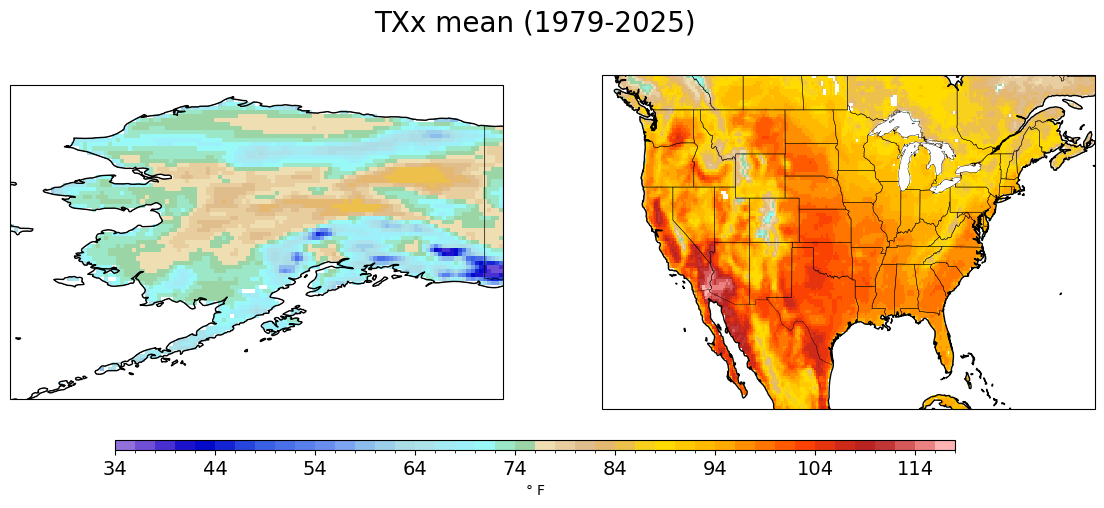

In [56]:
cmap=cmaps.amwg256
proj=ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,5),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15, right=0.9)

cc=Tmean.sel(lon=slice(190,220),lat=slice(53,72)).plot(ax=ax[0],cmap=cmap,levels=np.arange(34,120,2),add_colorbar=False)
ax[0].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.3) 
ax[0].coastlines()

cc=Tmean.sel(lon=slice(230,300),lat=slice(22,52)).plot(ax=ax[1],cmap=cmap,levels=np.arange(34,120,2),add_colorbar=False)
ax[1].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.3) 
ax[1].coastlines()
ax_cbar = fig.add_axes([0.2, 0.1, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,\
        shrink=0.5,\
        orientation='horizontal',label=units)
cbar.ax.tick_params(labelsize=14)

asp = np.diff(ax[0].get_xlim())[0] / np.diff(ax[0].get_ylim())[0]
ax[1].set_aspect(asp)
plt.suptitle(f'TXx mean ({yearb}-{yeare})', fontsize=20)

Text(0.5, 0.98, 'TXx Standard Deviation (1979-2025)')

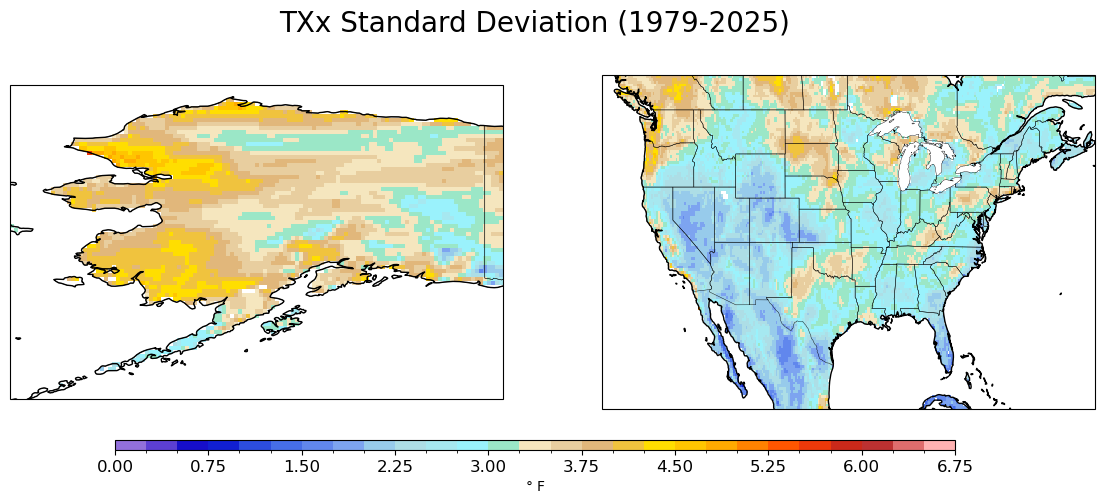

In [57]:
cmap=cmaps.amwg256
proj=ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,5),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15, right=0.9)

cc=Tstd.sel(lon=slice(190,220),lat=slice(53,72)).plot(ax=ax[0],cmap=cmap,levels=np.arange(0,7,0.25),add_colorbar=False)
ax[0].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.3) 
ax[0].coastlines()

cc=Tstd.sel(lon=slice(230,300),lat=slice(22,52)).plot(ax=ax[1],cmap=cmap,levels=np.arange(0,7,0.25),add_colorbar=False)
ax[1].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.3) 
ax[1].coastlines()
ax_cbar = fig.add_axes([0.2, 0.1, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,\
        shrink=0.5,\
        orientation='horizontal',label=units)
cbar.ax.tick_params(labelsize=12)

asp = np.diff(ax[0].get_xlim())[0] / np.diff(ax[0].get_ylim())[0]
ax[1].set_aspect(asp)
plt.suptitle(f'TXx Standard Deviation ({yearb}-{yeare})', fontsize=20)

Text(0.5, 0.98, 'TXx Skewness (1979-2025)')

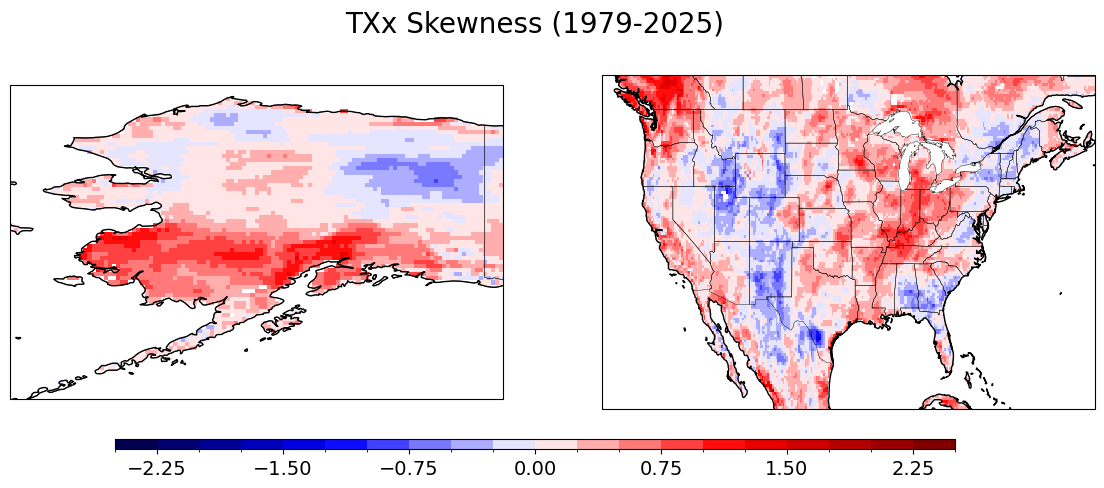

In [63]:
cmap='seismic'
proj=ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,5),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15, right=0.9)

cc=Tskewness.sel(lon=slice(190,220),lat=slice(53,72)).plot(ax=ax[0],cmap=cmap,levels=np.arange(-2.5,2.75,0.25),add_colorbar=False)
ax[0].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.3) 
ax[0].coastlines()

cc=Tskewness.sel(lon=slice(230,300),lat=slice(22,52)).plot(ax=ax[1],cmap=cmap,levels=np.arange(-2.5,2.75,0.25),add_colorbar=False)
ax[1].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.3) 
ax[1].coastlines()
ax_cbar = fig.add_axes([0.2, 0.1, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,\
        shrink=0.5,\
        orientation='horizontal',label='')
cbar.ax.tick_params(labelsize=14)

asp = np.diff(ax[0].get_xlim())[0] / np.diff(ax[0].get_ylim())[0]
ax[1].set_aspect(asp)
plt.suptitle(f'TXx Skewness ({yearb}-{yeare})', fontsize=20)

Text(0.5, 0.98, 'TXx: Nb of value above 2$\\sigma$ (1979-2025)')

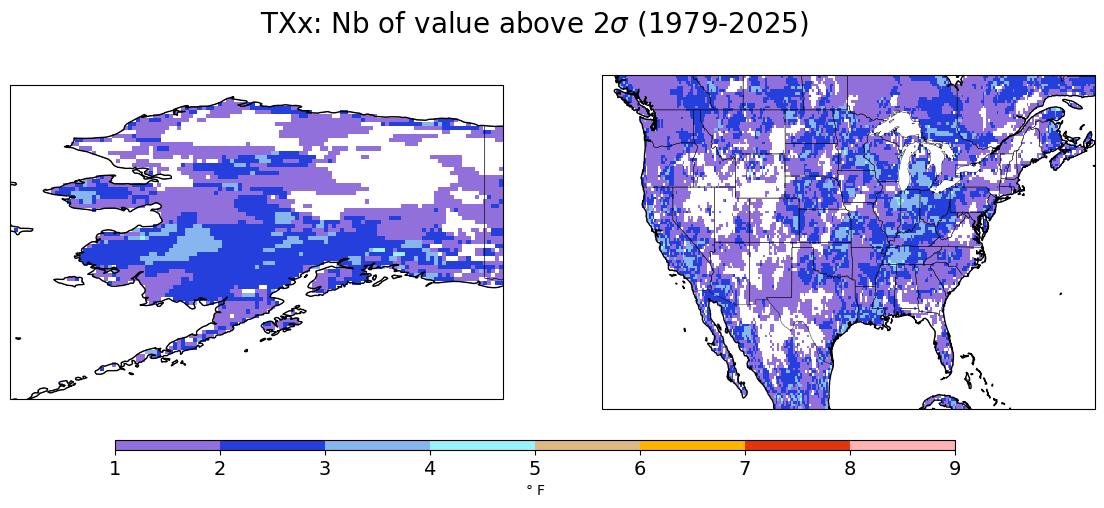

In [64]:
cmap=cmaps.amwg256
proj=ccrs.PlateCarree()
fig, ax = plt.subplots(nrows=1,ncols=2,figsize=(14,5),subplot_kw={'projection':proj})
plt.subplots_adjust(bottom=0.15, right=0.9)

cc=Touliers.sel(lon=slice(190,220),lat=slice(53,72)).plot(ax=ax[0],cmap=cmap,levels=np.arange(1,10,1.),add_colorbar=False)
ax[0].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.3) 
ax[0].coastlines()

cc=Touliers.sel(lon=slice(230,300),lat=slice(22,52)).plot(ax=ax[1],cmap=cmap,levels=np.arange(1,10,1.),add_colorbar=False)
ax[1].add_feature(state_borders,zorder=100,edgecolor='k',linewidth=0.3) 
ax[1].coastlines()
ax_cbar = fig.add_axes([0.2, 0.1, 0.6, 0.02])
cbar=fig.colorbar(cc,cax=ax_cbar,\
        shrink=0.5,\
        orientation='horizontal',label=units)
cbar.ax.tick_params(labelsize=14)

asp = np.diff(ax[0].get_xlim())[0] / np.diff(ax[0].get_ylim())[0]
ax[1].set_aspect(asp)
plt.suptitle(f'TXx: Nb of value above 2$\sigma$ ({yearb}-{yeare})', fontsize=20)